# Physical Derivation

The dataset used (https://www.kaggle.com/datasets/cici118/damped-harmonic-oscillator/data) tracks the position, velocity, and acceleration of a damped oscillating object of mass m = 1kg, spring constant k=1N/m, and damping coefficient c=0.1Ns/m. The oscillator initially is displaced by 1 meter and has a velocity of 0 m/s.


Given training data for this oscillator for the three kinematic values at many points in time, the three objectives with the model are to:
1. Reconstruct these original timestamps with position, velocity, acceleration
2. Extrapolate outside of the given region of time and predict these three quantities
3. Complete timestamps within the training dataset's time region but not given inside the dataset and predict these three quantites

Using the 2nd order ordinary differential equation for damped harmonic motion:
$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0$$
$$m\ddot{x} + c\dot{x} + kx = 0$$
$$(1.0kg) \cdot \ddot{x} + (0.1\frac{Ns}{m}) \cdot \dot{x} + (1.0\frac{N}{m}) \cdot x = 0$$

In a PINN, loss functions account for both data loss (deviation from the data points) and physics loss (deviation from known physics equations such as the one above). The physics loss in this situation comes from the root mean squared error (RMSE) of this left hand side from 0.

Combining these two loss values to get a singular loss, we use a tuned constant $\lambda$ weighting the physics loss, making the loss function:

$$L(x, \dot{x}, \ddot{x}, \hat{x}, \dot{\hat{x}}, \ddot{\hat{x}}) = L_{\text{data}} + \lambda \cdot L_{\text{physics}}$$
$$L(x, \dot{x}, \ddot{x}, \hat{x}, \dot{\hat{x}}, \ddot{\hat{x}}) = (\ddot{x}-\ddot{\hat{x}})^2 + (\dot{x}-\dot{\hat{x}})^2 + (x-\hat{x})^2 + \lambda \cdot (\ddot{\hat{x}} + 0.1\dot{\hat{x}} + \hat{x})^2$$

for one prediction, where the dots over the x's represent derivatives with respect to time and the hats represent the predicted values rather than ground truth ones.

# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

Mounted at /content/drive


# Importing Data

This dataset class stores the data internally and becomes an object to be used later on.

In [ ]:
class DampedOscillatorDataset(Dataset):
  def __init__(self, file_path):
    self.DataFrame = pd.read_csv(file_path) # initially read as pandas DF
    self.raw_data = self.DataFrame.to_numpy() # convert to numpy, eliminates col names
    print("Data type:", self.raw_data.dtype)
    self.X, self.y = self.raw_data[:, 0], self.raw_data[:, 1:] # split into input/output
    self.X = np.expand_dims(self.X, axis=1) # make each sample a 1d array of size 1
    print("X shape:", self.X.shape)
    print("Y shape:", self.y.shape)

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

Loading the data and seeing first few entries:

In [ ]:
train_data_file_path = "data/completion/train.csv"
dataset = DampedOscillatorDataset(train_data_file_path)
print("First 5 rows of input: \n", dataset.X[:5])
print("First 5 rows of output: \n", dataset.y[:5])

Data type: float64
X shape: (200, 1)
Y shape: (200, 3)
First 5 rows of input: 
 [[0.       ]
 [1.5075377]
 [3.0150754]
 [4.522613 ]
 [6.030151 ]]
First 5 rows of output: 
 [[ 1.          0.         -1.        ]
 [ 0.10670093 -0.92658556 -0.01404238]
 [-0.84717494 -0.11187882  0.85836285]
 [-0.19405991  0.78341     0.11571891]
 [ 0.7051903   0.19081393 -0.7242717 ]]


# EDA

Seeing the rough shape of the graphs of each of x, v, and a:

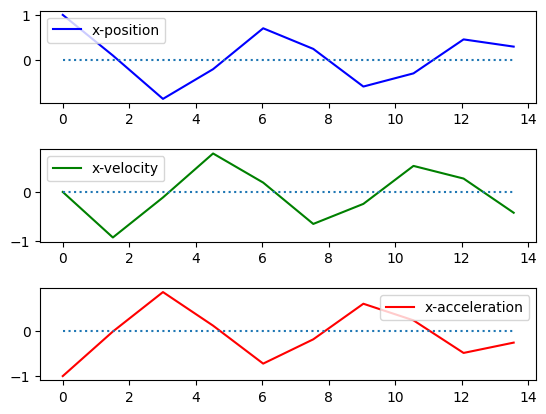

In [ ]:
t = np.squeeze(dataset.X) # make input 1d array again
x = dataset.y[:, 0]
v = dataset.y[:, 1]
a = dataset.y[:, 2]

graph_samples = 10

fig, ax = plt.subplots(3)
plt.subplots_adjust(hspace=0.5)

ax[0].plot(t[:graph_samples], x[:graph_samples], color='blue', label='x-position')
ax[0].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[0].legend()

ax[1].plot(t[:graph_samples], v[:graph_samples], color='green', label='x-velocity')
ax[1].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[1].legend()

ax[2].plot(t[:graph_samples], a[:graph_samples], color='red', label='x-acceleration')
ax[2].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[2].legend()

plt.show()

Finding the range of each column of the training dataset

In [ ]:
print("t range:", dataset.X.min(), dataset.X.max())
print("x range:", dataset.y[:, 0].min(), dataset.y[:, 0].max())
print("v range:", dataset.y[:, 1].min(), dataset.y[:, 1].max())
print("a range:", dataset.y[:, 2].min(), dataset.y[:, 2].max())

t range: 0.0 300.0
x range: -0.84717494 1.0
v range: -0.92658556 0.78341
a range: -1.0 0.85836285


In [ ]:
a_mean = np.mean(a)
v_mean = np.mean(v)
x_mean = np.mean(x)

# Training

Dividing the dataset into training and validation:

In [ ]:
# interleaved splitting to preserve temporal order

train_idx = []
val_idx = []

for i in range(len(dataset)):
  if i % 3 == 2:
    val_idx.append(i)

  else:
    train_idx.append(i)

train_data = torch.utils.data.Subset(dataset, train_idx)
val_data = torch.utils.data.Subset(dataset, val_idx)
print(train_idx)

[0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15, 16, 18, 19, 21, 22, 24, 25, 27, 28, 30, 31, 33, 34, 36, 37, 39, 40, 42, 43, 45, 46, 48, 49, 51, 52, 54, 55, 57, 58, 60, 61, 63, 64, 66, 67, 69, 70, 72, 73, 75, 76, 78, 79, 81, 82, 84, 85, 87, 88, 90, 91, 93, 94, 96, 97, 99, 100, 102, 103, 105, 106, 108, 109, 111, 112, 114, 115, 117, 118, 120, 121, 123, 124, 126, 127, 129, 130, 132, 133, 135, 136, 138, 139, 141, 142, 144, 145, 147, 148, 150, 151, 153, 154, 156, 157, 159, 160, 162, 163, 165, 166, 168, 169, 171, 172, 174, 175, 177, 178, 180, 181, 183, 184, 186, 187, 189, 190, 192, 193, 195, 196, 198, 199]


Normalizing the time:

In [ ]:
# normalizing data
t_mean = dataset.X[train_data.indices].mean()
t_std = dataset.X[train_data.indices].std()

dataset.X = (dataset.X - t_mean) / t_std

print(dataset.X)

t_mean_tensor = torch.tensor(t_mean, dtype=torch.float64)
t_std_tensor = torch.tensor(t_std, dtype=torch.float64)

[[-1.71494385]
 [-1.69770823]
 [-1.68047261]
 [-1.663237  ]
 [-1.64600138]
 [-1.62876576]
 [-1.61153015]
 [-1.59429453]
 [-1.57705891]
 [-1.55982329]
 [-1.54258768]
 [-1.52535207]
 [-1.50811645]
 [-1.49088083]
 [-1.47364521]
 [-1.45640959]
 [-1.43917397]
 [-1.42193836]
 [-1.40470273]
 [-1.38746712]
 [-1.3702315 ]
 [-1.35299588]
 [-1.33576027]
 [-1.31852466]
 [-1.30128905]
 [-1.28405343]
 [-1.26681781]
 [-1.24958219]
 [-1.23234657]
 [-1.21511095]
 [-1.19787536]
 [-1.18063971]
 [-1.1634041 ]
 [-1.14616848]
 [-1.12893286]
 [-1.11169725]
 [-1.09446161]
 [-1.07722601]
 [-1.05999039]
 [-1.04275477]
 [-1.02551915]
 [-1.00828353]
 [-0.99104791]
 [-0.97381234]
 [-0.9565767 ]
 [-0.93934111]
 [-0.92210552]
 [-0.90486988]
 [-0.88763424]
 [-0.8703986 ]
 [-0.85316302]
 [-0.83592742]
 [-0.81869178]
 [-0.80145614]
 [-0.78422054]
 [-0.76698497]
 [-0.74974932]
 [-0.73251368]
 [-0.71527804]
 [-0.69804245]
 [-0.68080686]
 [-0.66357122]
 [-0.64633558]
 [-0.62909994]
 [-0.61186436]
 [-0.59462876]
 [-0.57739

Creating the DataLoader objects that load batches efficiently in PyTorch:

In [ ]:
train_dataloader = DataLoader(train_data, batch_size=1, num_workers=2)
val_dataloader = DataLoader(val_data, batch_size=1, num_workers=2)

Checking batch sizes:

In [ ]:
for x, y in train_dataloader: # test one batch for shape
  print("X: ", x.shape)
  print("Y: ", y.shape)
  break

X:  torch.Size([1, 1])
Y:  torch.Size([1, 3])


This is the model class, containing the architecture.

In [ ]:
class FourierFeatures(nn.Module):
    def __init__(self, n_features=32, scale=10.0):
        super().__init__()
        B = torch.randn(1, n_features, dtype=torch.float64) * scale
        self.register_buffer('B', B) # fixes the frequencies while saving them

    def forward(self, t):
        proj = t @ self.B  # (batch, n_features)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (batch, 2*n_features)

class DampedOscillatorModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.fourier = FourierFeatures(n_features=32, scale=10.0)
    self.layers = nn.Sequential(
      # takes in time as a vector of 64 (because of fourier features)
      nn.Linear(64, 128),
      nn.Tanh(),
      nn.Linear(128, 128),
      nn.Tanh(),
      nn.Linear(128, 128),
      nn.Tanh(),
      nn.Linear(128, 1)
    )

  def forward(self, t):
    t_encoded = self.fourier(t)
    return self.layers(t_encoded)

  def predict(self, times):
    # getting all outputs from x
    times = times.requires_grad_(True)

    x = self.forward(times) # call the forward() function
    v = torch.autograd.grad(x.sum(), times, create_graph=True)[0]
    a = torch.autograd.grad(v.sum(), times, create_graph=True)[0]
    return x, v, a

Creating the model object and converting its parameters to doubles, which are more precise and match the data type of the data.

In [ ]:
model = DampedOscillatorModel()
model.double() # convert parameters to double (float64)

DampedOscillatorModel(
  (fourier): FourierFeatures()
  (layers): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Loss function and optimizer: very patient scheduler since this model takes a long time to converge.

In [ ]:
# criterion = nn.MSELoss() # default, reduction is 'mean'
optimizer = optim.Adam(model.parameters(), 3e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100)
# ^  LR scheduler to prevent overshooting

Loss function - an addition made to the loss function described at the top of the notebook is weighted loss, prioritizing earlier instances of time because they have more important signal: damping has a huge effect at later times and makes kinematic values essentially zero.

In [ ]:
def loss(labels, x, v, a, lamb_phys):
  # x, v, a, and all label columns are taken as 2d tensors, not 1d
  x_gt = labels[:, 0].unsqueeze(1)
  v_gt = labels[:, 1].unsqueeze(1)
  a_gt = labels[:, 2].unsqueeze(1)

  weights = (x_gt.abs()) ** 2 + 0.03
  weights = weights / weights.mean()

  mse_loss = torch.mean(weights * ((x_gt - x) ** 2 + (v_gt - v) ** 2 + (a_gt - a) ** 2))
  physics_loss = torch.mean( (1.0*a + 0.1*v + 1.0*x)**2 ) # ma+bv+x = 0
  train_loss = (mse_loss + lamb_phys * physics_loss)
  return train_loss # returns 1-element tensor

Defining variables to be used in the training loop. Again, the number of epochs is very high and model patience is set to the same number to not have early stopping.

In [ ]:
num_epochs = 1000
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_epoch = 0
model_patience = 1000

Training Loop

In [ ]:
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  lamb_phys = 0.0 if epoch < 20 else 0.05

  for times, labels in tqdm(train_dataloader, desc='Training...'):
    optimizer.zero_grad() # reset the gradients after each batch

    x, v, a = model.predict(times=times)
    # use chain rule to get actual derivatives
    v_real = v / t_std_tensor
    a_real = a / (t_std_tensor ** 2)
    # loss
    current_loss = loss(labels=labels, x=x, v=v_real, a=a_real, lamb_phys=lamb_phys)

    current_loss.backward() # backpropagation


    # nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping after backprop
    optimizer.step()

    # get the average loss and multiply by count, add to running total
    running_loss += current_loss.item() * times.size(0)

  train_loss = running_loss / len(train_dataloader.dataset)
  train_losses.append(train_loss)





  # validating
  model.eval()
  running_loss = 0.0
  current_loss = None
  # with torch.no_grad(): ???
  for times, labels in tqdm(val_dataloader, desc='Validating...'):
    # make prediction
    with torch.enable_grad():
      x, v, a = model.predict(times=times)

    with torch.no_grad():
      # use chain rule to get actual derivatives
      v_real = v / t_std_tensor
      a_real = a / (t_std_tensor ** 2)

      current_loss = loss(labels, x, v_real, a_real, lamb_phys=lamb_phys)
      running_loss += current_loss.item() * times.size(0)


  val_loss = running_loss / len(val_dataloader.dataset)
  val_losses.append(val_loss)



  scheduler.step(val_loss) # change the learning rate BASED ON VAL LOSS


  # save epoch and update loss, check for patience
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_epoch = epoch

    torch.save(model.state_dict(), 'best_model.pt')
    print(f"New best model saved at epoch {epoch+1}")
  elif epoch - best_epoch >= model_patience:
    print(f"Model has not improved in {model_patience} epochs - stopping now, best model was at epoch {best_epoch}")
    break


  print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")

Training...:   0%|          | 0/134 [00:00<?, ?it/s]

Validating...:   0%|          | 0/66 [00:00<?, ?it/s]

New best model saved at epoch 1
Epoch 1/1000 - Train loss: 0.06861357817615958, Validation loss: 0.05697833208217059


Training...:   0%|          | 0/134 [00:00<?, ?it/s]

Validating...:   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 50/1000 - Train loss: 0.11882091716602287, Validation loss: 99.75924744707808


Training...:   0%|          | 0/134 [00:00<?, ?it/s]

Validating...:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 51/1000 - Train loss: 0.19482694358947553, Validation loss: 18.990017875285282


Training...:   0%|          | 0/134 [00:00<?, ?it/s]

Checking std, mean of weights and outputs to check for model collapsing (having most weights essentially zero)

In [ ]:
for name, param in model.named_parameters():
    print(name, param.abs().mean().item())

model.eval()
t_all = torch.tensor(dataset.X, dtype=torch.float64)
x_pred, _, _ = model.predict(t_all)
print("predicted std:", torch.std(x_pred).item())
print("predicted range:", x_pred.min().item(), "to", x_pred.max().item())

# Visualizing Results

Checking loss values over time:

In [ ]:
epochs_ran = len(train_losses)
plt.plot([i for i in range(epochs_ran)], train_losses)
plt.plot([i for i in range(epochs_ran)], val_losses)
plt.show()

Graphing the predictions on the training/validation set with the ground truth labels to check how well the model fits:

In [ ]:
x_pred, _, _ = model.predict(torch.tensor(dataset.X))

plt.plot(dataset.X, dataset.y[:, 0])
plt.plot(dataset.X, x_pred.detach().numpy())
print(torch.std(x_pred))
plt.show()

print(dataset.y[:, 0])

# Testing Model

Creating data objects for each of the three testing datasets:

In [ ]:
completion_file_path = "data/completion/test.csv"
reconstruction_file_path = "data/reconstruction/test.csv"
extrapolation_file_path = "data/extrapolation/test.csv"

completion_dataset = DampedOscillatorDataset(completion_file_path)
reconstruction_dataset = DampedOscillatorDataset(reconstruction_file_path)
extrapolation_dataset = DampedOscillatorDataset(extrapolation_file_path)

completion_dataloader = DataLoader(completion_dataset, batch_size=1, num_workers=2)
reconstruction_dataloader = DataLoader(reconstruction_dataset, batch_size=1, num_workers=2)
extrapolation_dataloader = DataLoader(extrapolation_dataset, batch_size=1, num_workers=2)

Normalize using the same training normalizer - using different normalizing values would throw the model off completely

In [ ]:
# normalizing data
completion_dataset.X = (completion_dataset.X - t_mean) / t_std
reconstruction_dataset.X = (reconstruction_dataset.X - t_mean) / t_std
extrapolation_dataset.X = (extrapolation_dataset.X - t_mean) / t_std

Loading the model with the lowest validation loss obtained during training

In [ ]:
best_model = DampedOscillatorModel()
best_model.load_state_dict(torch.load('best_model.pt'))
best_model.double()

Running the best model through the three testing datasets and tracking losses:

In [ ]:
test_losses = [0, 0, 0]

running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(completion_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.05)
  running_loss += current_loss.item() * times.size(0)
test_losses[0] = running_loss / len(completion_dataset)


running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(reconstruction_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.05)
  running_loss += current_loss.item() * times.size(0)
test_losses[1] = running_loss / len(reconstruction_dataset)


running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(extrapolation_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.05)
  running_loss += current_loss.item() * times.size(0)
test_losses[2] = running_loss / len(extrapolation_dataset)




print("Completion test loss:", test_losses[0])
print("Reconstruction test loss:", test_losses[1])
print("Extrapolation test loss:", test_losses[2])